# Task 3: Exploratory Data Analysis on IPL Dataset

Dataset: `IPL_Ball_by_Ball_2008_2022.csv`, `IPL_Ball_by_Ball_2022.csv`, and `IPL_Matches_2022.csv`


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


## 1. Basic Data Preprocessing


In [18]:
ipl_all = pd.read_csv("C:/Users/tasik/Python/datasets/IPL_Ball_by_Ball_2008_2022.csv")
ball = pd.read_csv("C:/Users/tasik/Python/datasets/IPL_Ball_by_Ball_2022.csv")
match = pd.read_csv("C:/Users/tasik/Python/datasets/IPL_Matches_2022.csv")


In [19]:
print("All ball-by-ball shape:", ipl_all.shape)
print("2022 ball-by-ball shape:", ball.shape)
print("2022 matches shape:", match.shape)


All ball-by-ball shape: (225954, 17)
2022 ball-by-ball shape: (17912, 17)
2022 matches shape: (74, 20)


In [5]:
ball.info()


<class 'pandas.DataFrame'>
RangeIndex: 17912 entries, 0 to 17911
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID                 17912 non-null  int64
 1   innings            17912 non-null  int64
 2   overs              17912 non-null  int64
 3   ballnumber         17912 non-null  int64
 4   batter             17912 non-null  str  
 5   bowler             17912 non-null  str  
 6   non-striker        17912 non-null  str  
 7   extra_type         1050 non-null   str  
 8   batsman_run        17912 non-null  int64
 9   extras_run         17912 non-null  int64
 10  total_run          17912 non-null  int64
 11  non_boundary       17912 non-null  int64
 12  isWicketDelivery   17912 non-null  int64
 13  player_out         912 non-null    str  
 14  kind               912 non-null    str  
 15  fielders_involved  704 non-null    str  
 16  BattingTeam        17912 non-null  str  
dtypes: int64(9), str(8)
mem

In [6]:
ball.sample(2)


,ID,innings,overs,ballnumber,batter,bowler,non-striker,extra_type,batsman_run,extras_run,total_run,non_boundary,isWicketDelivery,player_out,kind,fielders_involved,BattingTeam
6222,1304095,2,14,1,DP Conway,PWH de Silva,MM Ali,NaN,0,0,0,0,1,DP Conway,caught,Shahbaz Ahmed,Chennai Super Kings
7241,1304090,1,0,3,JC Buttler,DR Sams,D Padikkal,NaN,1,0,1,0,0,NaN,NaN,NaN,Rajasthan Royals


## 2. Highest Wicket Taker in a Particular Season

The available match file contains the 2022 season, so the season-wise wicket analysis below is calculated for IPL 2022.


In [7]:
bowler_wicket_kinds = {
    "bowled", "caught", "caught and bowled", "lbw", "stumped", "hit wicket"
}

season_wickets = ball[ball["kind"].isin(bowler_wicket_kinds)].merge(
    match[["ID", "Season"]], on="ID", how="left"
)

wicket_counts = (
    season_wickets.groupby(["Season", "bowler"])
    .size()
    .rename("wickets")
    .reset_index()
)

top_idx = wicket_counts.groupby("Season")["wickets"].idxmax()
season_wicket_takers = wicket_counts.loc[top_idx].sort_values("Season")

season_wicket_takers

,Season,bowler,wickets
101,2022,YS Chahal,27


## 3. Player Records in IPL History

The following records are calculated from `IPL_Ball_by_Ball_2008_2022.csv`.


In [15]:
# 1. Most deliveries faced — a 'wide' isn't a ball faced by the batter
faced_counts = ball.loc[ball['extra_type'] != 'wides', 'batter'].value_counts()
top_faced = faced_counts.idxmax(), faced_counts.max()
top_faced

# 2. Most sixes
six_counts = ball.loc[ball['batsman_run'] == 6, 'batter'].value_counts()
top_sixes = six_counts.idxmax(), six_counts.max()
top_sixes
# 3. Most catches — credit the fielder; for 'caught and bowled' the bowler IS the catcher
caught = ball[ball['kind'].isin(['caught', 'caught and bowled'])]
catcher = caught['fielders_involved'].fillna(caught['bowler'])
catch_counts = catcher.value_counts()
top_catches = catch_counts.idxmax(), catch_counts.max()
top_catches
# 4. Most LBW wickets
lbw_counts = ball.loc[ball['kind'] == 'lbw', 'bowler'].value_counts()
top_lbw = lbw_counts.idxmax(), lbw_counts.max()
top_lbw

('JC Buttler', np.int64(579))

('JC Buttler', np.int64(45))

('R Parag', np.int64(17))

('Rashid Khan', np.int64(5))

## 4. Highest Run Getter in the Season and Chart

The available season mapping is for IPL 2022, so this table and chart show the highest run getter for the 2022 season.


[Text(3, 0, '451'),
 Text(3, 0, '458'),
 Text(3, 0, '460'),
 Text(3, 0, '468'),
 Text(3, 0, '481'),
 Text(3, 0, '483'),
 Text(3, 0, '487'),
 Text(3, 0, '508'),
 Text(3, 0, '616'),
 Text(3, 0, '863')]

Text(0.5, 0, 'Runs')

Text(0.5, 1.0, 'Top 10 Run Scorers — IPL 2022')

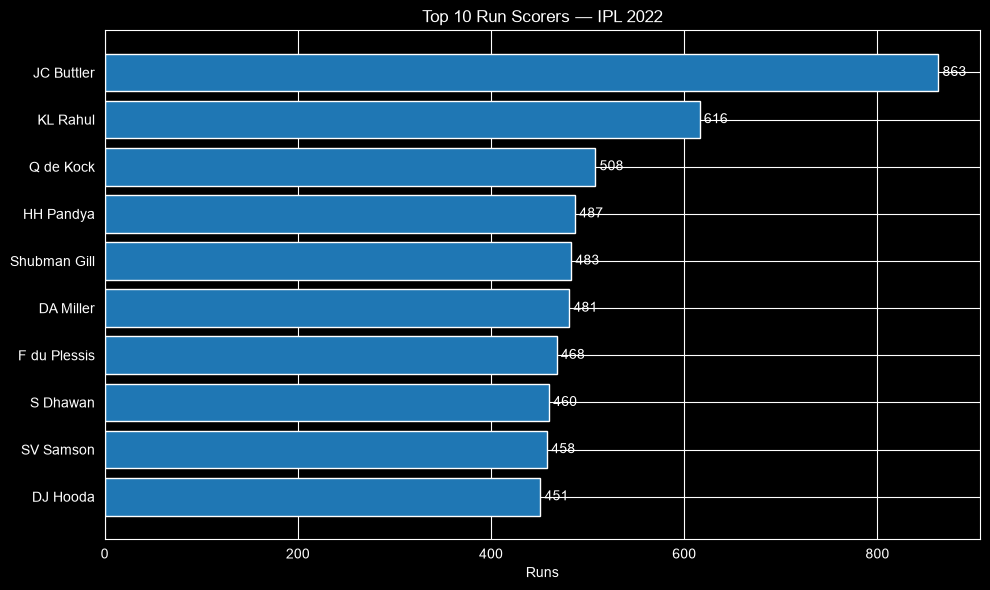

In [22]:

season_ball = ball.merge(match[["ID", "Season"]], on="ID", how="left")

season_runs = (
    season_ball.groupby(["Season", "batter"])["batsman_run"]
    .sum()
    .rename("runs")
    .reset_index()
)

# nlargest is O(n) vs sort_values + head on the full table
top10 = season_runs.nlargest(10, "runs").sort_values("runs")  # ascending for barh

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top10["batter"], top10["runs"], color="#1f77b4")
ax.bar_label(bars, padding=3)
ax.set_xlabel("Runs")
ax.set_title("Top 10 Run Scorers — IPL 2022")
plt.tight_layout()
plt.savefig("top10_runs.png", dpi=150)
plt.show()

## 5. Top 5 Batsmen by Strike Rate in IPL History

Only players who faced at least 50 legal deliveries are considered.


In [23]:
MIN_BALLS = 60  # ~10 overs faced — filters out small-sample noise

# Runs per batter (single groupby-sum, O(n))
runs = ball.groupby("batter")["batsman_run"].sum().rename("runs")

# Balls faced excludes wides (batter isn't credited a "faced" ball on a wide)
balls_faced = (
    ball.loc[ball["extra_type"] != "wides", "batter"]
    .value_counts()
    .rename("balls")
)

# Single concat instead of two merges
stats = pd.concat([runs, balls_faced], axis=1).dropna()
stats["strike_rate"] = (stats["runs"] / stats["balls"]) * 100

top5_sr = (
    stats[stats["balls"] >= MIN_BALLS]
    .nlargest(5, "strike_rate")
    .reset_index()
)
print(top5_sr)

           batter  runs  balls  strike_rate
0        TH David   186     86   216.279070
1      KD Karthik   330    180   183.333333
2  LS Livingstone   437    240   182.083333
3      AD Russell   335    192   174.479167
4      GJ Maxwell   301    178   169.101124


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('/Bangalore.csv')
print("First 5 rows of the dataset:")
display(df.head())
df.columns = df.columns.str.lower().str.replace(' ', '_')

target_column = None
potential_target_names = ['price', 'price_in_cr']
for col_name in potential_target_names:
    if col_name in df.columns:
        target_column = col_name
        break

if target_column is None:
    raise ValueError("Target column (price, rent, or price_in_lakhs) not found in the dataset.")

candidate_features = ['area', 'bhk', 'bathroom', 'resale', 'latitude', 'longitude', 'sq_ft', 'total_sqft']

selected_features = []
for feature_name in candidate_features:
    if feature_name in df.columns and df[feature_name].dtype in ['int64', 'float64']:
        selected_features.append(feature_name)

if len(selected_features) < 4:
    all_numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
    available_numerical_features = [col for col in all_numerical_cols if col != target_column and col not in selected_features]

    while len(selected_features) < 4 and available_numerical_features:
        selected_features.append(available_numerical_features.pop(0))

if len(selected_features) < 4:
    print(f"Warning: Only {len(selected_features)} features found. At least 4 features were requested. Proceeding with available features.")

print(f"Selected Features: {selected_features}")
print(f"Target Variable: {target_column}")

df_cleaned = df[selected_features + [target_column]].dropna()

X = df_cleaned[selected_features]
y = df_cleaned[target_column]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nShape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")
display(X_train.describe())
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Features scaled successfully!")